# Optimisation MILP du dimensionnement d'un système PV/batterie/réseau sous contrainte de couverture de charge (demande résidentielle), minimisation du coût total.  


**Résolution par Pyomo**  
Solveur: %pip install highspy

#### <u>Cas d'étude</u>:  
Répondre à une demande résidentielle électrique horaire.  
Sources mobilisables : **PV, batterie, réseau**.  

#### <u>Objectifs</u>:  
Quantifier le cout de la transiton énergétique; pour différents taux d'autoconsomation

#### <u>Récupérer les données</u>:
-Données de production d'un panneau PV à un endroit donné : donne production horaire  
-Données de prix (achat : contrat heure pleine/creuse et contrat spot et vente : prix fixe)  
-Données de consommation : rendue horaire à partir des coefficients de consommation horaire d'Enedis

### **Calcul du productible solaire**  
%pip install pvlib

Le modèle considère un panneau photovoltaïque monocristallin de 425 Wc représentatif du marché français actuel (DualSun Flash 425 Wc). 
Son coût complet installé (module, fixation, pose, câblage et maintenance) est approché par 1000 €/panneau.  
Le lieu choisi pour mettre les panneaux est Grenoble.

In [1]:
import pvlib
from pvlib.location import Location
from pvlib.modelchain import ModelChain
from pvlib.pvsystem import PVSystem, Array, FixedMount

#On veux les données pour grenoble : A remplacer si autre ville
latitude = 45.1885
longitude = 5.7247

loc = Location(
    latitude,
    longitude,
    tz="Europe/Paris",
    altitude=100,
    name="Grenoble"
)

#On a les paramètres d'ensoleillement pour Grenoble
weather, meta = pvlib.iotools.get_pvgis_tmy(
    latitude=latitude,
    longitude=longitude,
    map_variables=True
)

weather.index = weather.index.tz_convert("Europe/Paris")

#Panneau PV : A remplacer si autre panneau
panneau_DualSun_Flash_425_W = { 
        "pdc0":425, #Puissance crète nominale à 100W/m² et Temp ambiante (25°)
        "gamma_pdc":-0.0031 #Pertes d'efficacité selon température (%/°C)
    }

#Onduleur : à remplacer si onduleur différent
onduleur = {
        "pdc0":425,
        "eta_inv_nom":0.966, #Efficacité pour passer de Dc à AC
        "eta_inv_ref":0.9637
    }

#Paramètres du modèle thermique
temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS[
        "sapm"
    ]["open_rack_glass_glass"]
)

#On crée notre système (PV + onduleur)
system = PVSystem(
    arrays=[
        Array(
            mount=FixedMount(
                surface_tilt=30, #30°
                surface_azimuth=180 #Exposé Sud
            ),
            module_parameters=panneau_DualSun_Flash_425_W,
            temperature_model_parameters=temperature_model_parameters,
            modules_per_string=1,
            strings=1
        )
    ],
    inverter_parameters=onduleur
)

#On compte les pertes
mc = ModelChain.with_pvwatts(system, loc)

#On calcule la production horaire du panneau
mc.run_model(weather)

#La production en kwh
production_kwh = mc.results.ac / 1000

#Le df utilisé par pyomo
df_production_1pv = production_kwh.reset_index(drop=True)

#La production annuelle
print("La production totale annuelle du panneau PV est de : ", production_kwh.sum())


La production totale annuelle du panneau PV est de :  566.9837890975473


Caractéristiques économiques des panneaux solaires.  
**Modifiable selon le panneau d'étude**

In [2]:
prix_panneau_pv_sans_pose = 300 #€/panneau sans pose
#Environ 600€ pour la pose
#Donc prix total (avec maintenance (10%)) = 1000€
prix_panneau_pv = 1000 #tout inclus

Caractéristiques technico-économiques des batteries
**Modifiable selon la batterie d'étude**

In [3]:
#Données identifiées sur Internet

prix_kw_batterie = 0 #On met 0 car on oblige la batterie à prendre des valeurs discrètes donc le prix est déja porté par le prix au kwh.
prix_kwh_batterie = 1000 #petite batterie donc pas d'économie d'échelle
rendement_charge_batterie = 0.95
rendement_decharge_batterie = 0.95

#Discretisation : la batterie est dimensionée comme un nombre entier de
#modules standards empilables (type BYD Battery-Box Premium / Enphase IQ), (pas puissance/capacité continue)
#Hypothese par defaut : module de 2.5 kWh / 1.25 kW (ratio de puissance 0.5C).
capacite_module_batterie = 2.5   # kWh par module
puissance_module_batterie = 1.25  # kW par module


### **Récupération des prix de l'électricité (achat et vente)**    
%pip install entsoe-py

La clé API ENTSOE est récupérable en récupérant un compte ENTSOE sur la plateforme: https://transparency.entsoe.eu/  
Cela permet de récupérer les prix du contrat spot.  


In [4]:
import os
import getpass

# Demande la clé à l'utilisateur sans l'afficher à l'écran
api_key = getpass.getpass("Entrez votre clé API : ")

# Définit la variable d'environnement pour ce processus
os.environ["ENTSOE_API_KEY"] = api_key   

On étudie **deux contrats d'électricité** pour un particulier:  
-tarif fixe classique (heures pleines/creuses)    
-tarif dynamique (prix spot)


In [5]:
#Contrat d'achat

#CONTRAT FIXE
abonnement_annuel= 15.65*12 #€/an
abonnement_jour = abonnement_annuel/365 #€/jour
abonnement_heure = abonnement_jour/24 #€/h

#Heures creuses : 22h-6h et 12h-14h
prix_energie_heure_creuse = 0.1579 #€/kWh
#Heures pleines : 6h-12h et 14h-22h
prix_energie_heure_pleine = 0.2065 #€/kWh

prix_jour = []
for h in range(24):
    if (h >= 22 or h < 6) or (h >= 12 and h < 14):
        prix_jour.append(prix_energie_heure_creuse )
    else:
        prix_jour.append(prix_energie_heure_pleine)

df_achat_elec_contrat_fixe = []
for jour in range (365):
    df_achat_elec_contrat_fixe.extend(prix_jour)

#CONTRAT SPOT
from entsoe import EntsoePandasClient
import pandas as pd
import os
import numpy as np

def df_achat_elec_contrat_spot():

    api_key = os.environ.get("ENTSOE_API_KEY")
    if api_key is None:
        print("Cle API ENTSO-E introuvable (variable d'environnement ENTSOE_API_KEY absente). "
              "Le tarif spot ne sera pas calculé ; le notebook continue avec le contrat fixe.")
        return None

    client = EntsoePandasClient(api_key=api_key)

    #Definir la période (1 an complet) en Europe 
    start = pd.Timestamp('2025-01-01', tz='Europe/Paris')
    end = pd.Timestamp('2026-01-01', tz='Europe/Paris')

    df_prix = client.query_day_ahead_prices(country_code='FR', start=start, end=end)

    #On passe des €/MWh aux €/kWh
    df_prix = df_prix/1000

    #Car on a des données horaires, d'autres sous forme 15 min
    df_prix = df_prix.resample("1h").mean()

    #index 0...8759 pour Pyomo
    df_prix = df_prix.reset_index(drop=True)

    return df_prix[:8760]

#On récupère le contrat
df_achat_elec_contrat_spot = df_achat_elec_contrat_spot()
#Caractéristiques des prix
print("Le min des prix du contrat spot est :", min(df_achat_elec_contrat_spot))
print("Le max des prix du contrat spot est :", max(df_achat_elec_contrat_spot))
print("La moyenne des prix du contrat spot est :", np.mean(df_achat_elec_contrat_spot))
#print(len(df_achat_elec_contrat_spot))

#Contrat de vente: 1.1cts/kwh : prix fixe
df_vente_elec = pd.Series(
    0.011,
    index=range(8760)
)

Le min des prix du contrat spot est : -0.11801
Le max des prix du contrat spot est : 0.47328
La moyenne des prix du contrat spot est : 0.061073417332572294


### **Récupération de la demande électrique d'un foyer**  
On utilise les coefficients d'enedis: https://opendata.enedis.fr/datasets/coefficients-des-profils/table  
Cela donne des coefficients de consommation horaires sur 1 an.  
On normalise les valeurs (somme des coeffs sur l'année = 1) et on ventile la consommation annuelle selon les coeffs horaires.  
Cela donne la consommation horaire de la maison.  

In [6]:
import pandas as pd

#Fichier public Enedis 
coeffs_enedis = "coefficients-des-profils.csv"

df_coeffs = pd.read_csv(coeffs_enedis,sep=",")

df_demande = df_coeffs[["HORODATE", "COEFFICIENT_AJUSTE"]].copy()
df_demande.columns = ["date", "coeffs"]
df_demande["date"] = pd.to_datetime(df_demande["date"], utc=True)
df_demande = df_demande.set_index("date") #mise en index de la colonne
df_demande = df_demande.resample("h").mean() #conversion en donnees horaires

# Choix d'une année : 2025 (complète)
df_demande = df_demande.loc["2025"]

#Normalisation
df_demande ["coeffs_normalise"] = df_demande["coeffs"] / df_demande["coeffs"].sum() #normalisation des coefficients
#On verifie qu'on a bien une somme de 1
#print(df_demande["coeffs_normalise"].sum())

#Fixer une conso annuelle : 4500 kwh/an : hypothèse réaliste pour un foyer francais.
demande_annuelle_elec_kwh = 4500
#Ventilée par heure sur 1 an
df_demande["demande elec kwh"] = df_demande["coeffs_normalise"] * demande_annuelle_elec_kwh

#Le df à utiliser plus tard
demande = df_demande["demande elec kwh"]
#print(demande.head())
print(demande.sum()) #verification de la somme des demandes
print("La demande max horaire est de :", demande.max()) #verification de la demande maximale
print("La demande min horaire est de :", demande.min()) #verification de la demande minimale
print("La demande moyenne horaire est de :", np.mean(demande))

4500.0
La demande max horaire est de : 1.06021923401457
La demande min horaire est de : 0.25120160850174916
La demande moyenne horaire est de : 0.5136986301369864


### **Annualisation du capex (Capital Recovery Factor)**  
Remarque:   
PV : fort Capex (si cout complet; alors solveur choisira jamais d'installer du PV).  
Objectif: Annualiser le cout du CAPEX.  
Facteur de récupération du capital (CRF): répartit le cout d'achat sur la durée de vie de l'équipement 

In [7]:
# Annualisation du capex (Capital Recovery Factor)

taux_actualisation = 0.04  # hypothese : 4%, taux d'actualisation pour un menage
#Taux doit etre >0 sinon plante dans analyse sensibilité

duree_vie_pv = 25          # ans, durée de vie typique d'un panneau PV
duree_vie_batterie = 12    # ans, durée de vie typique d'une batterie Li-ion residentielle

def crf(taux, duree):
    return taux * (1 + taux)**duree / ((1 + taux)**duree - 1)

CRF_pv = crf(taux_actualisation, duree_vie_pv)
CRF_batterie = crf(taux_actualisation, duree_vie_batterie)

print(f"CRF PV : {CRF_pv:.4f} (soit {CRF_pv*100:.2f} % du capex payé chaque année)")
print(f"CRF batterie : {CRF_batterie:.4f} (soit {CRF_batterie*100:.2f} % du capex payé chaque année)")


CRF PV : 0.0640 (soit 6.40 % du capex payé chaque année)
CRF batterie : 0.1066 (soit 10.66 % du capex payé chaque année)


## Scenarios : quel est le "coût de la transition" pour ce foyer ?

Ce qu'on constate si on laisse le solveur choisir : appel majoritaire au réseau, achat de 2 panneaux pour compléter le réseau et 0 batterie.

<u>Ce qu'on décide alors de faire</u>:  
**Imposer comme contrainte un certain taux d'auto-consommation.**  
Cela permettra de voir le cout nécessaire pour réaliser la transition énergétique.  
Le solveur optimisera alors au cout minimal le mix énergétique (pv, batterie, réseau) pour répondre à la demande et respecter le taux d'autoconsommation.

<u>Le taux d'autoconsommation</u>:   
Défini initialement comme la somme annuelle du pv + batterie comme un % de la demande.  
Problème : trading d'électricité qui apparait : on charge/décharge la batterie à partir du réseau: on reste dépendant du réseau, pas d'autoconsommation.  
Solution : imposer un max d'électricité venant du réseau pour répondre à la demande.  


**A propos du champ `status`** :  
`optimal` signifie que HiGHS a trouvé (à la tolérance `mip_gap` près) la meilleure solution  
`infeasible` (aucune solution ne satisfait toutes les contraintes)  
`maxTimeLimit` (le solveur a ete arreté avant preuve d'optimalité).

#### **Modélisation du problème sur Pyomo**

Le modèle est défini dans le readme.

In [8]:
import pyomo.environ as pyo
import pandas as pd

def construire_et_resoudre_modele(df_achat_elec_prix, taux_autoproduction_min=None,
                                   autoriser_deconnexion_reseau=False,
                                   autoriser_arbitrage_trading_batterie = False,
                                   mip_gap=0.01,
                                   prix_panneau_pv_override=None,
                                   prix_kw_batterie_override=None,
                                   prix_kwh_batterie_override=None,
                                   taux_actualisation_override=None,
                                   duree_vie_pv_override=None,
                                   duree_vie_batterie_override=None,
                                   facteur_inflation_energie=1.0):
    """
    Construit et résout le problème de dimensionnement PV + batterie + reseau.

    df_achat_elec_prix : serie de prix d'achat horaires (€/kWh), longueur 8760.

    taux_autoproduction_min : float entre 0 et 1, ou None. 
    Si fourni, impose un taux maximum d'appel au réseau (le reste venant du PV)

    autoriser_deconnexion_reseau : si True, un binaire rend l'abonnement reseau optionnel.

    mip_gap : tolérance d'optimalité relative pour HiGHS.

    *_override : permettent de faire varier un paramètre économique (prix PV,
        prix batterie, taux d'actualisation, duree de vie) sans toucher aux
        hypothèses globales du notebook -- utilisé pour l'analyse de sensibilité.
        Si non fourni, la valeur globale du notebook est utilisée par defaut.

    facteur_inflation_energie : multiplicateur appliqué aux prix d'achat et de vente
        (les deux séries, uniformement), pour simuler un horizon pluriannuel avec
        inflation de l'energie sans reconstruire le MILP sur plusieurs années --
        voir facteur_ajustement_inflation() plus bas dans le notebook. Par defaut 1.0
        (pas d'ajustement, comportement 1 an inchangé).

    Retourne un dict avec les résultats, la décomposition du cout par poste,
    un diagnostic sur l'origine de l'énergie de la batterie, et le modèle
    Pyomo résolu (pour extraire des series horaires si besoin).
    """

    model = pyo.ConcreteModel()
    model.time = pyo.RangeSet(1, 8760) #Nombre d'heures dans une année

    # --------------
    # Parametres du modele utilisés dans l'analyse de sensivité
    # --------------

    prix_panneau_pv_val = prix_panneau_pv_override if prix_panneau_pv_override is not None else prix_panneau_pv
    prix_kw_batterie_val = prix_kw_batterie_override if prix_kw_batterie_override is not None else prix_kw_batterie
    prix_kwh_batterie_val = prix_kwh_batterie_override if prix_kwh_batterie_override is not None else prix_kwh_batterie
    taux_actu_val = taux_actualisation_override if taux_actualisation_override is not None else taux_actualisation
    duree_pv_val = duree_vie_pv_override if duree_vie_pv_override is not None else duree_vie_pv
    duree_batt_val = duree_vie_batterie_override if duree_vie_batterie_override is not None else duree_vie_batterie
    CRF_pv_val = crf(taux_actu_val, duree_pv_val)
    CRF_batterie_val = crf(taux_actu_val, duree_batt_val)

    # --------------
    # Parametres du modele
    # --------------

    model.prix_panneau_pv = pyo.Param(initialize=prix_panneau_pv_val) 
    model.prix_kw_batterie = pyo.Param(initialize=prix_kw_batterie_val) 
    model.prix_kwh_batterie = pyo.Param(initialize=prix_kwh_batterie_val) 
    model.rendement_charge_batterie = pyo.Param(initialize=rendement_charge_batterie)
    model.rendement_decharge_batterie = pyo.Param(initialize=rendement_decharge_batterie)
    model.abonnement_annuel_elec = pyo.Param(initialize=abonnement_annuel)

    #Annualisation du capex (CRF calculés plus haut)
    model.CRF_pv = pyo.Param(initialize=CRF_pv_val)
    model.CRF_batterie = pyo.Param(initialize=CRF_batterie_val)

    #Caracteristiques du module batterie standard (discrétisation)
    model.capacite_module_batterie = pyo.Param(initialize=capacite_module_batterie)
    model.puissance_module_batterie = pyo.Param(initialize=puissance_module_batterie)

    #Charger les dataseries des prix horaires sur 1 an
    #ACHAT ELEC (facteur_inflation_energie appliqué ici)
    df_achat_elec = pd.Series(df_achat_elec_prix).reset_index(drop=True) * facteur_inflation_energie
    model.prix_achat_electricite = pyo.Param(model.time, domain=pyo.Reals, initialize=lambda model, t: df_achat_elec.iloc[t-1]) #Dynamique

    #VENTE ELEC (meme facteur, uniforme achat/vente)
    df_vente_elec_serie = pd.Series(df_vente_elec).reset_index(drop=True) * facteur_inflation_energie
    model.prix_vente_electricite = pyo.Param(model.time, domain=pyo.Reals, initialize=lambda model, t: df_vente_elec_serie.iloc[t-1]) 

    #DEMANDE ELEC
    df_demande = demande.reset_index(drop=True)
    model.demande_electricite = pyo.Param(model.time, domain=pyo.NonNegativeReals, initialize=lambda model, t: df_demande.iloc[t-1])

    #PRODUCTION PV
    df_production_1pv = production_kwh.reset_index(drop=True)
    model.production_1pv = pyo.Param(model.time, domain=pyo.NonNegativeReals, initialize=lambda model, t: df_production_1pv.iloc[t-1])

    # --------------
    # Variables d'optimisation
    # --------------

    #Variables de dimensionnement
    model.nombre_panneaux_pv = pyo.Var(domain=pyo.NonNegativeIntegers) #Le nombre de panneaux trouvés par le solveur

    #Batterie dimensionnée par un nombre entier de modules standards (discretisation realiste)
    model.nb_modules_batterie = pyo.Var(domain=pyo.NonNegativeIntegers) #Le nombre de batteries (taille fixe)
    model.pmax_batterie = pyo.Var(domain=pyo.NonNegativeReals) #La puissance max des batteries (charge/décharge)
    model.estock_max_batterie = pyo.Var(domain=pyo.NonNegativeReals) #Combien on peut stocker au max dans les batteries

    #Variables de flux
    model.achat_electricite = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Combien on achète d'électricité
    model.vente_electricite = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Combien on vend d'électricité
    model.pv_maison = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Part d'électricité allant du pv à la maison
    model.pv_batterie = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Part d'électricité allant du pv à la batterie
    model.pv_grid = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Part d'électricité allant du pv à la grid
    model.grid_batterie = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Part d'électricité allant de la grid à la batterie
    model.grid_maison = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Part d'électricité allant de la grid à la maison
    model.batterie_maison = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Part d'électricité allant de la batterie à la maison
    model.batterie_grid = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Part d'électricité allant de la batterie à la grid
    model.echarge = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Combien on charge la batterie à l'instant t
    model.edecharge = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Combien on décharge la batterie à l'instant t
    model.estock_batterie = pyo.Var(model.time, domain=pyo.NonNegativeReals) #Combien on a en stock dans la batterie à l'instant t

    #Déconnexion du réseau : on peut se déconnecter du réseau et pas payer l'abonnement
    if autoriser_deconnexion_reseau:
        model.connecte_reseau = pyo.Var(domain=pyo.Binary)
        M_grid = 30  # borne large sur achat/vente horaire
        model.achat_si_connecte = pyo.Constraint(model.time, rule=lambda m, t: m.achat_electricite[t] <= M_grid * m.connecte_reseau)
        model.vente_si_connecte = pyo.Constraint(model.time, rule=lambda m, t: m.vente_electricite[t] <= M_grid * m.connecte_reseau)
    else:
        model.connecte_reseau = pyo.Param(initialize=1)

    # --------------
    # Definir la fonction objectif (capex annualise via CRF + opex annuel)
    # --------------

    model.obj = pyo.Objective(expr = model.abonnement_annuel_elec * model.connecte_reseau + 
                            model.nombre_panneaux_pv * model.prix_panneau_pv * model.CRF_pv +
                            model.pmax_batterie * model.prix_kw_batterie * model.CRF_batterie + 
                            #Ici ne compte pas car valeurs discrètes de batteries mais fonctionnerait pour trouver le meilleur ratio kWh/kw adapté au problème; 
                            #pas forcément commercialisé
                            model.estock_max_batterie * model.prix_kwh_batterie * model.CRF_batterie +
                            sum(model.achat_electricite[t] * model.prix_achat_electricite[t]
                                - model.vente_electricite[t] * model.prix_vente_electricite[t] 
                                for t in model.time), sense=pyo.minimize)

    # --------------
    # Contraintes
    # --------------

    #Bilan PV : ce qu'on produit va soit alimenter la maison, la batterie ou la grid
    def rule_bilan_pv(model, t):
        return model.production_1pv[t] * model.nombre_panneaux_pv == \
                model.pv_maison[t] + model.pv_batterie[t] + model.pv_grid[t]
    model.bilan_pv = pyo.Constraint(model.time, rule=rule_bilan_pv)

    #Bilan achat réseau: alimente soit la maison, soit la batterie
    if autoriser_arbitrage_trading_batterie == True:
        def rule_bilan_grid_achat(model, t):
            return model.achat_electricite[t] == model.grid_batterie[t] + model.grid_maison[t]
        model.bilan_grid_achat = pyo.Constraint(model.time, rule=rule_bilan_grid_achat)
    else:
        def rule_bilan_grid_achat(model, t):
            return model.achat_electricite[t] == model.grid_maison[t]
        model.bilan_grid_achat = pyo.Constraint(model.time, rule=rule_bilan_grid_achat)
        # On fixe grid_batterie à 0 pour que le solveur ne plante pas
        model.pas_de_charge_batterie_par_reseau = pyo.Constraint(model.time, rule=lambda model, t: model.grid_batterie[t] == 0)

    #Bilan vente électricité : soit électricité PV soit batterie alimentant le réseau 
    def rule_bilan_grid_vente(model, t):
        return model.vente_electricite[t] == model.batterie_grid[t] + model.pv_grid[t]
    model.bilan_grid_vente = pyo.Constraint(model.time, rule=rule_bilan_grid_vente)

    #Bilan de chargement de la batterie:  ce qui charge la batterie : ce qui va du réseau vers la batterie et du pv vers la batterie
    if autoriser_arbitrage_trading_batterie == True:
        def rule_echargement_batterie(model, t):
            return model.grid_batterie[t] + model.pv_batterie[t] == model.echarge[t]
        model.echargement_batterie = pyo.Constraint(model.time, rule=rule_echargement_batterie)
    else:
        def rule_echargement_batterie(model, t):
            return model.pv_batterie[t] == model.echarge[t]
        model.echargement_batterie = pyo.Constraint(model.time, rule=rule_echargement_batterie)

    #Bilan déchargement de la batterie : ce qui va sur le réseau, et dans la maison
    def rule_dechargement_batterie(model, t):
        return model.batterie_maison[t] + model.batterie_grid[t] == model.edecharge[t]
    model.dechargement_batterie = pyo.Constraint(model.time, rule=rule_dechargement_batterie)

    #Niveau de charge de la batterie : niveau de charge précédent + flux absolus (avec les rendements de charge/décharge)
    #Cycle meme niveau à la fin de l'année et au début (optimise pour éviter que niveau initial nul et autoconsommation 100% sans pv durant la nuit)
    def rule_estock_batterie(model, t):
        t_precedent = t - 1 if t > 1 else 8760
        return model.estock_batterie[t] == model.estock_batterie[t_precedent] + model.echarge[t]*model.rendement_charge_batterie - model.edecharge[t]/model.rendement_decharge_batterie
    model.estock_batterie_contrainte = pyo.Constraint(model.time, rule=rule_estock_batterie)

    #Contraintes physiques sur la batterie (min d'énergie stockée et max)
    model.e_min = pyo.Constraint(model.time, rule=lambda model, t: model.estock_batterie[t] >= 0)
    model.e_max = pyo.Constraint(model.time, rule=lambda model, t: model.estock_batterie[t] <= model.estock_max_batterie)

    #La puissance max de charge/décharge possible
    model.pmax_charge = pyo.Constraint(model.time, rule=lambda model, t: model.echarge[t] <= model.pmax_batterie)
    model.pmax_decharge = pyo.Constraint(model.time, rule=lambda model, t: model.edecharge[t] <= model.pmax_batterie)

    #Capacité de la batterie = somme des capacités des batteries (différents modules) / pareil pour puissance
    model.lien_capacite_batterie = pyo.Constraint(rule=lambda model: model.estock_max_batterie == model.nb_modules_batterie * model.capacite_module_batterie)
    model.lien_puissance_batterie = pyo.Constraint(rule=lambda model: model.pmax_batterie == model.nb_modules_batterie * model.puissance_module_batterie)

    #Bilan de la maison : ce qui peut alimenter la maison : grid + batterie + pv
    def rule_bilan_maison(model, t):
        return model.demande_electricite[t] == model.pv_maison[t] + model.grid_maison[t] + model.batterie_maison[t]
    model.bilan_maison = pyo.Constraint(model.time, rule=rule_bilan_maison)

    #Taux d'autoconsommation minimal : on peut faire appel au réseau que pour un pourcentage maximal (le reste devant provenir du PV + batterie)
    #On peut imaginer que le réseau charge la batterie (moins cher que le PV) mais une partie devra obligatoirement provenir du PV (taux_autoproduction_min)
    if taux_autoproduction_min is not None:
        def rule_taux_autoproduction(model):
            return sum(model.achat_electricite[t] for t in model.time) <= \
                    taux_autoproduction_min * sum(model.demande_electricite[t] for t in model.time)
        model.contrainte_autoproduction = pyo.Constraint(rule=rule_taux_autoproduction)

    # --------------
    # Resolution
    # --------------

    solver = pyo.SolverFactory("highs")
    solver.options["mip_rel_gap"] = mip_gap #La tolérance sur la meilleure valeur qu'on accepte
    result = solver.solve(model)

    # --------------
    # Décomposition du cout total par poste
    # --------------
    #Abonnement
    cout_abonnement = pyo.value(model.abonnement_annuel_elec * model.connecte_reseau)
    #PV
    cout_capex_pv = pyo.value(model.nombre_panneaux_pv * model.prix_panneau_pv * model.CRF_pv)
    #Batterie
    cout_capex_batterie = pyo.value((model.pmax_batterie * model.prix_kw_batterie + model.estock_max_batterie * model.prix_kwh_batterie) * model.CRF_batterie)
    #Grid
    cout_achat_elec = pyo.value(sum(model.achat_electricite[t] * model.prix_achat_electricite[t] for t in model.time))
    cout_vente_elec = pyo.value(sum(model.vente_electricite[t] * model.prix_vente_electricite[t] for t in model.time))
    cout_net_energie = cout_achat_elec - cout_vente_elec

    # --------------
    # Les Flux totaux
    # --------------
    #PV
    total_pv_maison = sum(pyo.value(model.pv_maison[t]) for t in model.time) #Ce qui alimente la maison
    total_pv_batterie = sum(pyo.value(model.pv_batterie[t]) for t in model.time) #Ce qui alimente la batterie
    total_pv_grid = sum(pyo.value(model.pv_grid[t]) for t in model.time) #Ce qui alimente la grid
    #Grid
    total_grid_batterie = sum(pyo.value(model.grid_batterie[t]) for t in model.time)
    total_grid_maison = sum(pyo.value(model.grid_maison[t]) for t in model.time)
    #Batterie
    total_batterie_maison = sum(pyo.value(model.batterie_maison[t]) for t in model.time)
    total_batterie_grid = sum(pyo.value(model.batterie_grid[t]) for t in model.time)
    total_charge = total_pv_batterie + total_grid_batterie #Egal à total décharge
    part_charge_batterie_pv = (total_pv_batterie / total_charge) if total_charge > 1e-6 else None #Savoir combien vient du réseau et combien du PV pour charger la batterie
    #Demande
    total_demande = sum(pyo.value(model.demande_electricite[t]) for t in model.time)
    total_pv_maison = sum(pyo.value(model.pv_maison[t]) for t in model.time) #Combien est alimentée par le PV
    total_batterie_maison = sum(pyo.value(model.batterie_maison[t]) for t in model.time) #Combien est alimentée par la batterie
    total_grid_maison = sum(pyo.value(model.grid_maison[t]) for t in model.time) #Combien est alimentée par la grid
    #Part de la demande répondue par chacun des flux : PV, batterie, grid
    part_demande_pv = total_pv_maison / total_demande
    part_demande_batterie = total_batterie_maison / total_demande
    part_demande_grid = total_grid_maison / total_demande

    #Ce qu'on renvoit
    return {
        #Les paramètres de la simulation
        "taux_autoproduction_min": taux_autoproduction_min if taux_autoproduction_min is not None else 0.0,
        "status": str(result.solver.termination_condition),
        "prix_panneau_pv_val": prix_panneau_pv_val,
        "prix_kw_batterie_val": prix_kw_batterie_val,
        "prix_kwh_batterie_val": prix_kwh_batterie_val,
        "taux_actu_val": taux_actu_val,
        "duree_pv_val": duree_pv_val,
        "duree_batt_val": duree_batt_val,
        "CRF_pv_val": CRF_pv_val,
        "CRF_batterie_val": CRF_batterie_val,
  
        #Les variables de dimensionnement
        "n_pv": pyo.value(model.nombre_panneaux_pv),
        "n_batt": pyo.value(model.nb_modules_batterie),
        "pmax_batterie_kw": pyo.value(model.pmax_batterie),
        "emax_batterie_kwh": pyo.value(model.estock_max_batterie),

        #Le modèle
        "model": model,
        
        #Poste de couts
        #Total
        "cout_annualise_eur": pyo.value(model.obj),
        #Réseau
        "connecte_reseau": pyo.value(model.connecte_reseau),
        "cout_abonnement_eur": cout_abonnement,
        #PV
        "cout_capex_pv_eur": cout_capex_pv,
        #Batterie
        "cout_capex_batterie_eur": cout_capex_batterie,
        #Electricité
        "cout_achat_elec_eur": cout_achat_elec,
        "cout_vente_elec_eur": cout_vente_elec, 
        "cout_total_elec_eur": cout_net_energie,

        #Flux
        #PV
        "total_pv_maison" : total_pv_maison,
        "total_pv_batterie" : total_pv_batterie,
        "total_pv_grid" : total_pv_grid,
        #Grid
        "total_grid_batterie" : total_grid_batterie,
        "total_grid_maison" : total_grid_maison,
        #Batterie
        "total_batterie_maison" : total_batterie_maison,
        "total_batterie_grid" : total_batterie_grid,
        "total_charge" : total_charge,
        "part_charge_batterie_pv" : part_charge_batterie_pv,
        #Demande
        "total_demande" : total_demande,

        #Part de la demande répondue par chacun des flux : PV, batterie, grid
        "part_demande_pv" : part_demande_pv,
        "part_demande_batterie" : part_demande_batterie,
        "part_demande_grid" : part_demande_grid,

    }

### **Taux d'autoconsommation minimal: va de 0 à 100%.**  
On va voir ce que ça coûte à des particuliers qui souhaiteraient faire cela.  

*Précision* : la variable `taux` passée au modèle est un plafond sur l'appel réseau (achat_electricite <= taux * demande), donc le taux d'autoconsommation réellement garanti est (1 - taux), pas taux directement.

### **Contrat fixe**

In [ ]:
#Le taux d'autoconsommation détermine ici combien d'appel au réseau sur l'année (max un % de la demande)

# Balayage de scenarios de taux d'autoproduction imposé (contrat fixe)
taux_scenarios = [1.0, 0.8, 0.6, 0.4, 0.2, 0.0] #On commence par 100% max de réseau (0% autoconsommation possible, et on finit à 0% max de réseau, donc 100% autoconsommation)

resultats_scenarios_contrat_fixe = []
for taux in taux_scenarios:
    modele = construire_et_resoudre_modele(df_achat_elec_contrat_fixe, taux_autoproduction_min=taux) #Renvoie un dictionnaire
    resultats_scenarios_contrat_fixe.append(modele)
    print(f"Plafond réseau <= {taux:.0%} de la demande (autoconsommation >= {1-taux:.0%}) -> "
          f"{modele['n_pv']:.0f} panneaux, {modele['n_batt']:.0f} modules batterie, avec "
          f"{modele['pmax_batterie_kw']} de puissance totale et {modele['emax_batterie_kwh']} de capacité totales, "
          f"cout annualise = {modele['cout_annualise_eur']:.0f} €/an  ({modele['status']})")

#Colonnes qui nous intéressent
colonnes = ["taux_autoproduction_min","n_pv", "n_batt", "pmax_batterie_kw","emax_batterie_kwh","cout_annualise_eur","cout_total_elec_eur","part_demande_grid","part_demande_pv", "part_demande_batterie"]

df_scenarios = pd.DataFrame([{k: modele[k] for k in colonnes} for modele in resultats_scenarios_contrat_fixe])
df_scenarios["surcout_vs_optimum_libre_eur"] = df_scenarios["cout_annualise_eur"] - df_scenarios["cout_annualise_eur"].iloc[0]
df_scenarios

### **Contrat spot**

In [ ]:
#Le taux d'autoconsommation détermine ici combien d'appel au réseau sur l'année (max un % de la demande)

# Balayage de scenarios de taux d'autoproduction imposé (contrat spot)
taux_scenarios = [1.0, 0.8, 0.6, 0.4, 0.2, 0.0] #On commence par 100% max de réseau (0% autoconsommation possible, et on finit à 0% max de réseau, donc 100% autoconsommation)

resultats_scenarios_contrat_spot = []
for taux in taux_scenarios:
    modele = construire_et_resoudre_modele(df_achat_elec_contrat_spot, taux_autoproduction_min=taux) #Renvoie un dictionnaire
    resultats_scenarios_contrat_spot.append(modele)
    print(f"Plafond réseau <= {taux:.0%} de la demande (autoconsommation >= {1-taux:.0%}) -> "
          f"{modele['n_pv']:.0f} panneaux, {modele['n_batt']:.0f} modules batterie, avec "
          f"{modele['pmax_batterie_kw']} de puissance totale et {modele['emax_batterie_kwh']} de capacité totales, "
          f"cout annualise = {modele['cout_annualise_eur']:.0f} €/an  ({modele['status']})")

#Colonnes qui nous intéressent
colonnes = ["taux_autoproduction_min","n_pv", "n_batt", "pmax_batterie_kw","emax_batterie_kwh","cout_annualise_eur","cout_total_elec_eur","part_demande_grid","part_demande_pv", "part_demande_batterie"]

df_scenarios = pd.DataFrame([{k: modele[k] for k in colonnes} for modele in resultats_scenarios_contrat_spot])
df_scenarios["surcout_vs_optimum_libre_eur"] = df_scenarios["cout_annualise_eur"] - df_scenarios["cout_annualise_eur"].iloc[0]
df_scenarios

### **Couts par poste**
Le but est de voir la part de chaque source dans le coût final.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dataframe_repartition_couts(resultats):
    lignes = []
    for r in resultats:
        total = r["cout_annualise_eur"] #Le cout total
        #On ajoute le % des couts
        lignes.append({
            "taux": r["taux_autoproduction_min"],
            "Abonnement": r["cout_abonnement_eur"] / total * 100,
            "PV": r["cout_capex_pv_eur"] / total * 100,
            "Batterie": r["cout_capex_batterie_eur"] / total * 100,
            "Electricite": r["cout_total_elec_eur"] / total * 100, #achat - vente
        })
    return pd.DataFrame(lignes).sort_values("taux")

def plot_repartition_couts(df, titre):
    postes = ["Abonnement", "PV", "Batterie", "Electricite"] #Les différents postes
    couleurs = {"Abonnement": "tab:gray", "PV": "tab:orange", "Batterie": "tab:green", "Electricite": "tab:blue"} #1 couleur par poste

    fig, ax = plt.subplots(figsize=(9, 6))
    bottom = np.zeros(len(df))
    for poste in postes:
        vals = df[poste].values
        ax.bar(df["taux"] * 100, vals, bottom=bottom, width=8, label=poste, color=couleurs[poste])
        for x, b, v in zip(df["taux"] * 100, bottom, vals):
            if v > 3:  # évite d'écrire dans les tranches trop fines
                ax.text(x, b + v / 2, f"{v:.0f}%", ha="center", va="center", fontsize=8, color="white")
        bottom += vals

    ax.set_xlabel("Plafond d'achat réseau autorisé (%)")
    ax.set_ylabel("Part du coût total (%)")
    ax.set_title(titre)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show() 

Répartition des couts pour les contrat fixe et spot

In [ ]:
df_couts_fixe = dataframe_repartition_couts(resultats_scenarios_contrat_fixe)
plot_repartition_couts(df_couts_fixe, "Répartition du coût par poste — contrat fixe")  

df_couts_spot = dataframe_repartition_couts(resultats_scenarios_contrat_spot)
plot_repartition_couts(df_couts_spot, "Répartition du coût par poste — contrat spot")    

### **Flux par source d'énergie**
Voir comment la demande est répondue par les sources

In [ ]:
#Une fiche récapitulative par modèle

def fiche_modele(r, titre=""):
    print(f"=== {titre} (plafond réseau = {r['taux_autoproduction_min']:.0%}) — statut : {r['status']} ===")
    print(f"Dimensionnement : {r['n_pv']:.0f} panneaux PV, {r['n_batt']:.0f} modules batterie "
          f"({r['pmax_batterie_kw']:.1f} kW / {r['emax_batterie_kwh']:.1f} kWh)")
    print(f"Coût annualisé total : {r['cout_annualise_eur']:.0f} €/an")
    print(f"  dont abonnement      : {r['cout_abonnement_eur']:.0f} €/an")
    print(f"  dont capex PV        : {r['cout_capex_pv_eur']:.0f} €/an")
    print(f"  dont capex batterie  : {r['cout_capex_batterie_eur']:.0f} €/an")
    print(f"  dont énergie nette   : {r['cout_total_elec_eur']:.0f} €/an "
          f"(achat {r['cout_achat_elec_eur']:.0f} - vente {r['cout_vente_elec_eur']:.0f})")
    print(f"Couverture demande : PV {r['part_demande_pv']:.0%}, batterie {r['part_demande_batterie']:.0%}, "
          f"réseau {r['part_demande_grid']:.0%}")
    print()

#Comment on répond à la demande à chaque heure

def plot_couverture_demande(r, titre="", h_debut=1, h_fin=8740):
    m = r["model"]
    pv = [pyo.value(m.pv_maison[t]) for t in range(h_debut, h_fin+1)]
    batt = [pyo.value(m.batterie_maison[t]) for t in range(h_debut, h_fin+1)]
    grid = [pyo.value(m.grid_maison[t]) for t in range(h_debut, h_fin+1)]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.stackplot(range(h_debut, h_fin+1), pv, batt, grid,
                 labels=["PV -> maison", "Batterie -> maison", "Réseau -> maison"],
                 colors=["tab:orange", "tab:green", "tab:blue"])
    ax.set_title(f"Couverture de la demande — {titre} (plafond réseau {r['taux_autoproduction_min']:.0%})")
    ax.set_xlabel("Heure de l'année")
    ax.set_ylabel("kWh/h")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

Résultats pour contrat standard

In [ ]:
#Les résultats
for r in resultats_scenarios_contrat_fixe:
    fiche_modele(r, "Contrat fixe")
    plot_couverture_demande(r, "Contrat fixe", h_debut=1, h_fin=168)        # semaine d'hiver
    plot_couverture_demande(r, "Contrat fixe", h_debut=4344, h_fin=4511)    # semaine d'été (mi juin)

Résultats pour contrat spot

In [ ]:
for r in resultats_scenarios_contrat_spot:
    fiche_modele(r, "Contrat spot")
    plot_couverture_demande(r, "Contrat spot", h_debut=1, h_fin=168)        # semaine d'hiver
    plot_couverture_demande(r, "Contrat spot", h_debut=4344, h_fin=4511)    # semaine d'été (~mi-juin)

### **Flux énergétiques mensuels**

Trois graphes complementaires aux fiches par scenario : une vue agrégée par mois (plus
lisible que 8760 points pour montrer la saisonnalité), un nuage de points pour verifier
que le modele achete bien preferentiellement aux heures les moins chères sous contrat
spot, et l'etat de charge de la batterie sur l'annee entiere (cycles saisonniers).


In [ ]:
# Vue mensuelle empilee : PV / batterie / reseau -> maison, par mois
import pandas as pd
import matplotlib.pyplot as plt

def plot_couverture_mensuelle(r, titre=""):
    m = r["model"]
    pv = [pyo.value(m.pv_maison[t]) for t in m.time]
    batt = [pyo.value(m.batterie_maison[t]) for t in m.time]
    grid = [pyo.value(m.grid_maison[t]) for t in m.time]

    # Index horaire arbitraire sur une annee non bissextile pour regrouper par mois
    index_heures = pd.date_range("2025-01-01", periods=8760, freq="h")
    df_flux = pd.DataFrame({"PV": pv, "Batterie": batt, "Reseau": grid}, index=index_heures)
    df_mensuel = df_flux.resample("ME").sum()
    df_mensuel.index = df_mensuel.index.strftime("%b")

    fig, ax = plt.subplots(figsize=(10, 4))
    df_mensuel.plot(kind="bar", stacked=True, ax=ax,
                     color=["tab:orange", "tab:green", "tab:blue"])
    ax.set_ylabel("kWh / mois")
    ax.set_title(f"Couverture mensuelle de la demande — {titre} (plafond reseau {r['taux_autoproduction_min']:.0%})")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# Exemple sur un scenario de 20% d'autoconsommation (80% de plafond reseau) pour chaque contrat
idx_80 = taux_scenarios.index(0.8)
plot_couverture_mensuelle(resultats_scenarios_contrat_fixe[idx_80], "Contrat fixe")
plot_couverture_mensuelle(resultats_scenarios_contrat_spot[idx_80], "Contrat spot")

# Exemple sur un scenario de 60% d'autoconsommation (40% de plafond reseau) pour chaque contrat
idx_60 = taux_scenarios.index(0.4)
plot_couverture_mensuelle(resultats_scenarios_contrat_fixe[idx_60], "Contrat fixe")
plot_couverture_mensuelle(resultats_scenarios_contrat_spot[idx_60], "Contrat spot")

# Exemple sur un scenario de 100% d'autoconsommation (0% de plafond reseau) pour chaque contrat
idx_100 = taux_scenarios.index(0)
plot_couverture_mensuelle(resultats_scenarios_contrat_fixe[idx_100], "Contrat fixe")
plot_couverture_mensuelle(resultats_scenarios_contrat_spot[idx_100], "Contrat spot")


In [ ]:
# Etat de charge de la batterie sur l'annee entiere (cycles saisonniers)
def plot_soc_annuel(r, titre=""):
    m = r["model"]
    estock = [pyo.value(m.estock_batterie[t]) for t in m.time]

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(range(1, 8761), estock, color="tab:green", linewidth=0.8)
    ax.set_xlabel("Heure de l'annee")
    ax.set_ylabel("Etat de charge (kWh)")
    ax.set_title(f"Etat de charge de la batterie sur l'annee — {titre} (plafond reseau {r['taux_autoproduction_min']:.0%})")
    plt.tight_layout()
    plt.show()

plot_soc_annuel(resultats_scenarios_contrat_fixe[idx_60], "Contrat fixe")
plot_soc_annuel(resultats_scenarios_contrat_spot[idx_60], "Contrat spot")


### **Rentabilité du PV et Batterie en années**

Le but est de déterminer la durée à laquelle le prix du PV et de la batterie deviendront économiques (rivalisant avec une connexion à 100% pour les besoins, sans autoconsommation)

Coût de référence (tout réseau, rien d'installé).  
C'est un point de comparaison (particulier uniquement connecté au réseau); pas d'autoconsommation

In [ ]:
#Cout annualise si le foyer achete tout au reseau, sans PV ni batterie
#Sert de point d ancrage / reference pour les seuils de prix ci-dessous et pour comparer aux résultats des scenarios

def cout_reference_tout_reseau(df_achat_elec_prix):
    df_achat = pd.Series(df_achat_elec_prix).reset_index(drop=True)
    df_dem = demande.reset_index(drop=True)
    cout_energie = sum(df_dem.iloc[t] * df_achat.iloc[t] for t in range(8760))
    return abonnement_annuel + cout_energie

On calcule la durée pour que les technologies deviennent plus économiques que la connexion réseau sans autoconsommation.  
On résout les deux équations de prix en appliquant un taux dégressif du prix des technologies.  
On obtient la durée.

In [ ]:
import numpy as np

def ecart_temporel(t, taux, prix_pv_actuel, prix_batt_actuel, declin_pv, declin_batt, df_achat_elec_prix):
    # Application du déclin géométrique des prix du CAPEX
    prix_pv_t = prix_pv_actuel * (1 - declin_pv) ** t
    prix_batt_t = prix_batt_actuel * (1 - declin_batt) ** t
    
    #Modèle Pyomo avec ces paramètres
    r = construire_et_resoudre_modele(
        df_achat_elec_prix, 
        taux_autoproduction_min=taux,
        prix_panneau_pv_override=prix_pv_t,
        prix_kwh_batterie_override=prix_batt_t,
    )
    
    return r['cout_annualise_eur'] - cout_reference_tout_reseau(df_achat_elec_prix)

def determiner_annee_rentabilite_robuste(taux, prix_pv_actuel, prix_batt_actuel, declin_pv, declin_batt,
                                         df_achat_elec_prix, horizon_max=40):
    """
    Méthode par balayage annuel, ultra-robuste pour les solveurs d'optimisation (Pyomo).
    Evite les pièges de non-dérivabilité et de non-monotonie.
    """
    # Vérification immédiate à t=0 (aujourd'hui)
    ecart_actuel = ecart_temporel(0, taux, prix_pv_actuel, prix_batt_actuel, declin_pv, declin_batt, df_achat_elec_prix)
    if ecart_actuel <= 0:
        return 0.0  # Déjà rentable aujourd'hui
        
    # Balayage année par année
    precedent_t = 0
    precedent_ecart = ecart_actuel
    
    for t in range(1, horizon_max + 1):
        actuel_ecart = ecart_temporel(t, taux, prix_pv_actuel, prix_batt_actuel, declin_pv, declin_batt, df_achat_elec_prix)
        
        # Si l'écart devient négatif ou nul, nous avons croisé le point d'égalisation
        if actuel_ecart <= 0:
            # Interpolation linéaire exacte entre t-1 et t pour trouver la racine
            fraction = precedent_ecart / (precedent_ecart - actuel_ecart)
            annee_exacte = precedent_t + fraction
            return round(annee_exacte, 1)
            
        # Archivage pour le prochain pas
        precedent_t = t
        precedent_ecart = actuel_ecart
        
    return None  # Pas rentable même après horizon_max années


On trouve les temporalités pour scénarios de taux de déclins fixes

In [ ]:
scenarios_declin = {"pessimiste": (0.03, 0.03), "central": (0.06, 0.12), "optimiste": (0.10, 0.20)} #Taux de déclin PV, batterie

for taux in [0.4, 0.0]:  # 20% / 60% / 100% d'autoconsommation
    for nom, (d_pv, d_batt) in scenarios_declin.items():
        annee = determiner_annee_rentabilite_robuste(taux, prix_panneau_pv, prix_kwh_batterie, d_pv, d_batt, df_achat_elec_contrat_fixe)
        libelle = f"{annee:.1f} ans" if annee is not None else f"> {40} ans"
        print(f"Autoconsommation {1-taux:.0%}, scénario {nom} -> rentable dans {libelle}")

## Analyse de sensibilité

Les hypothèses de couts (PV, batterie, taux d'actualisation, duree de vie) sont discutables.  
C'est le but de cette section : voir à quel point le dimensionnement optimal (nombre de
panneaux, nombre de modules batterie) et le cout total en dependent.     
On fait varier un parametre à la fois (les autres restant à leur valeur par défaut), sur le contrat fixe,
avec taux d'autoconsommation de 60%.


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

def balayer_parametre(nom_parametre, valeurs, **kwargs_fixes):
    """Fait varier un seul parametre économique et retourne un DataFrame de resultats."""
    lignes = []
    for v in valeurs:
        kwargs = {nom_parametre: v}
        kwargs.update(kwargs_fixes)
        r = construire_et_resoudre_modele(df_achat_elec_contrat_fixe, taux_autoproduction_min=0.4 , **kwargs)
        lignes.append({
            "valeur": v,
            "n_pv": r["n_pv"],
            "n_batt": r["n_batt"],
            "cout_annualise_eur": r["cout_annualise_eur"],
        })
    return pd.DataFrame(lignes)

def plot_sensibilite(df, xlabel, titre):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.plot(df["valeur"], df["n_pv"], marker="o", label="Nb panneaux PV")
    ax1.plot(df["valeur"], df["n_batt"], marker="s", label="Nb modules batterie")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Nombre d'unites")
    ax1.set_title("Dimensionnement optimal")
    ax1.legend()

    ax2.plot(df["valeur"], df["cout_annualise_eur"], marker="o", color="tab:red")
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel("Cout annualise (€/an)")
    ax2.set_title("Cout total")

    fig.suptitle(titre)
    plt.tight_layout()
    plt.show()


### Sensibilite au prix du panneau PV pose

Hypothese de base : 1000 €/panneau pose. On teste une plage de -50% a +60% pour couvrir
l'incertitude sur le cout de pose et les variations de marché du matériel.


   valeur  n_pv  n_batt  cout_annualise_eur
0     500  13.0     1.0         1141.337896
1     700   6.0     2.0         1301.933863
2     850   6.0     2.0         1359.544630
3    1000   6.0     2.0         1417.155396
4    1200   6.0     2.0         1493.969752
5    1400   6.0     2.0         1570.784107
6    1600   6.0     2.0         1647.598462


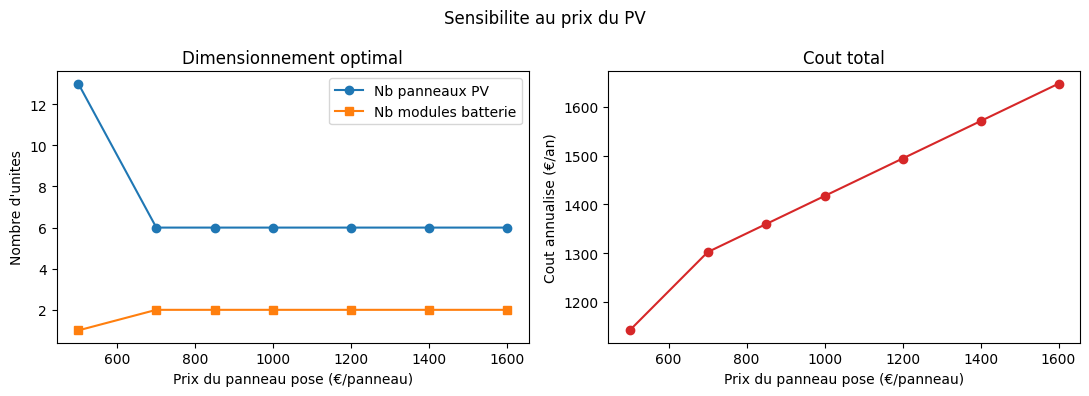

In [10]:
valeurs_prix_pv = [500, 700, 850, 1000, 1200, 1400, 1600]
df_sens_prix_pv = balayer_parametre("prix_panneau_pv_override", valeurs_prix_pv)
print(df_sens_prix_pv)
plot_sensibilite(df_sens_prix_pv, "Prix du panneau pose (€/panneau)", "Sensibilite au prix du PV")

### Sensibilité au prix de la batterie

On fait varier les deux composantes du cout batterie (€/kW et €/kWh) simultanement via un
multiplicateur, pour representer une baisse ou hausse generale du cout de la technologie
(comme observe historiquement sur le marche des batteries Li-ion) plutot que deux prix
independants.


   valeur  n_pv  n_batt  cout_annualise_eur
0    0.50   6.0     2.0         1150.774964
1    0.70   6.0     2.0         1257.327137
2    0.85   6.0     2.0         1337.241267
3    1.00   6.0     2.0         1417.155396
4    1.15   6.0     2.0         1497.069526
5    1.30   6.0     2.0         1576.983655
6    1.50   6.0     2.0         1683.535828


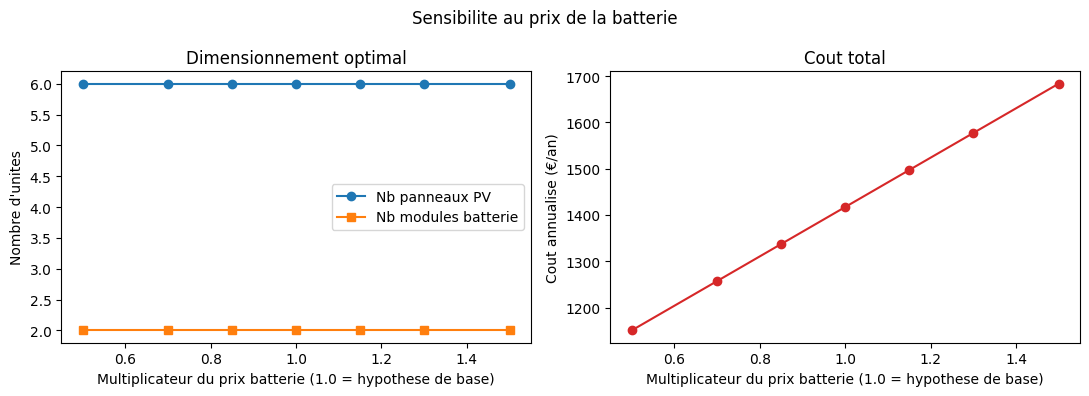

In [11]:
multiplicateurs_batterie = [0.5, 0.7, 0.85, 1.0, 1.15, 1.3, 1.5]

lignes = []
for m in multiplicateurs_batterie:
    r = construire_et_resoudre_modele(
        df_achat_elec_contrat_fixe,
        prix_kw_batterie_override=prix_kw_batterie * m,
        prix_kwh_batterie_override=prix_kwh_batterie * m,
        taux_autoproduction_min=0.4
    )
    lignes.append({"valeur": m, "n_pv": r["n_pv"], "n_batt": r["n_batt"], "cout_annualise_eur": r["cout_annualise_eur"]})

df_sens_batterie = pd.DataFrame(lignes)
print(df_sens_batterie)
plot_sensibilite(df_sens_batterie, "Multiplicateur du prix batterie (1.0 = hypothese de base)", "Sensibilite au prix de la batterie")


### Sensibilité au taux d'actualisation

Le taux d'actualisation traduit le "prix du temps" pour le menage (opportunité d'utiliser
cet argent autrement). Hypothèse de base : 4%. On teste de 1% (très favorable à
l'investissement long terme) à 8% (menage qui valorise fortement la liquidité immediate).


   valeur  n_pv  n_batt  cout_annualise_eur
0    0.01   6.0     2.0         1217.007220
1    0.02   6.0     2.0         1280.443370
2    0.04   6.0     2.0         1417.155396
3    0.06   6.0     2.0         1566.068212
4    0.08   6.0     2.0         1725.870515


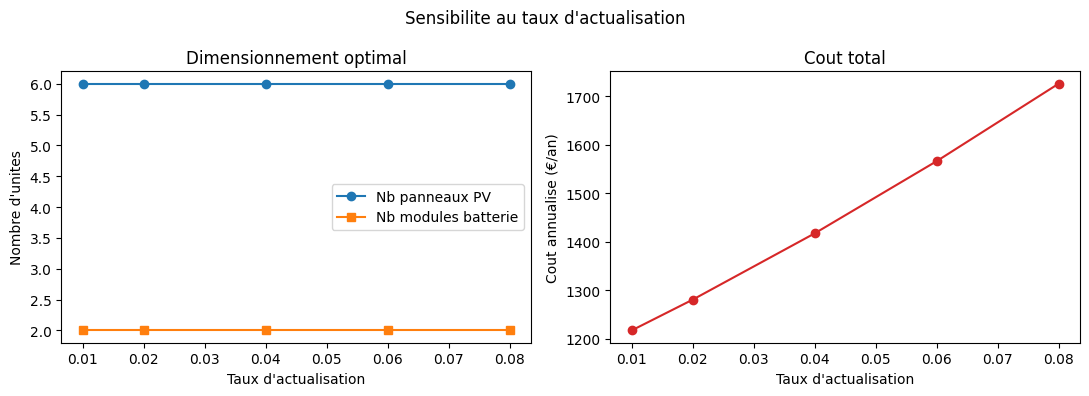

In [12]:
valeurs_taux = [0.01, 0.02, 0.04, 0.06, 0.08]
df_sens_taux = balayer_parametre("taux_actualisation_override", valeurs_taux)
print(df_sens_taux)
plot_sensibilite(df_sens_taux, "Taux d'actualisation", "Sensibilite au taux d'actualisation")


### Sensibilité à la duree de vie de la batterie

Hypothese de base : 12 ans. Les batteries Li-ion résidentielles récentes annoncent parfois
des durées de vie plus longues (garanties 15-20 ans à capacité réduite) ou au contraire plus
courtes en usage intensif -- on teste cette plage.


   valeur  n_pv  n_batt  cout_annualise_eur
0       6  13.0     1.0         1767.939979
1       8   6.0     2.0         1627.033693
2      10   6.0     2.0         1500.849254
3      12   6.0     2.0         1417.155396
4      15   6.0     2.0         1334.100035
5      18   6.0     2.0         1279.361173
6      20   6.0     2.0         1252.303284


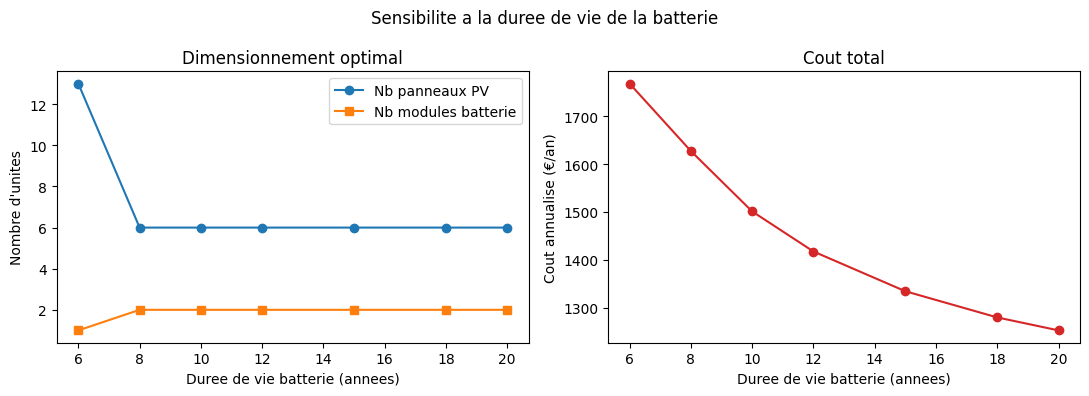

In [13]:
valeurs_duree_batterie = [6, 8, 10, 12, 15, 18, 20]
df_sens_duree_batt = balayer_parametre("duree_vie_batterie_override", valeurs_duree_batterie)
print(df_sens_duree_batt)
plot_sensibilite(df_sens_duree_batt, "Duree de vie batterie (annees)", "Sensibilite a la duree de vie de la batterie")


### Vue combinée : prix PV x prix batterie

Les deux leviers les plus incertains combinés en une seule carte de chaleur, pour visualiser
les zones ou la batterie devient intéressante.


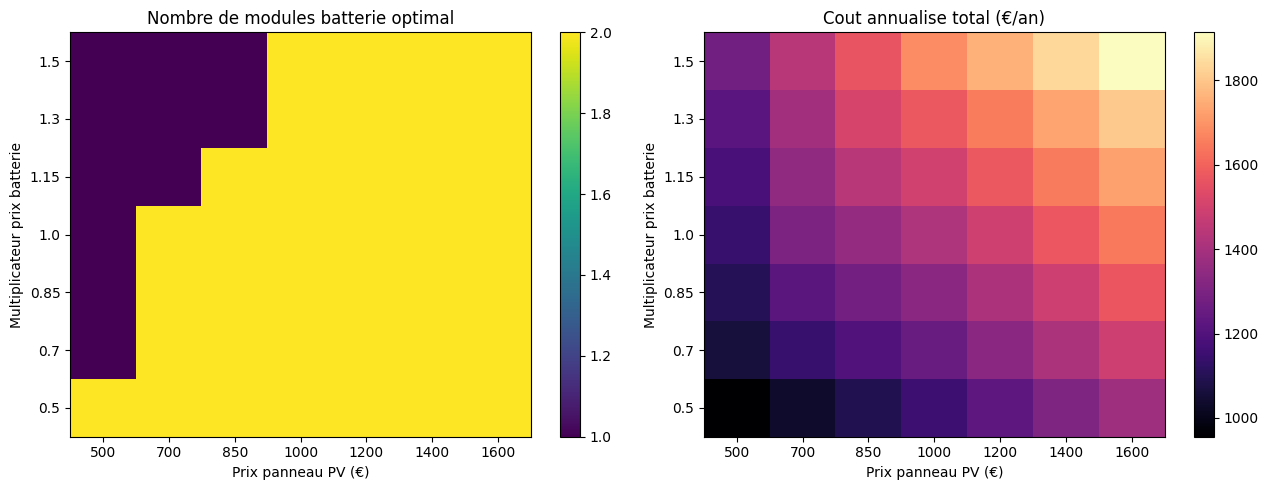

In [14]:
import numpy as np

valeurs_prix_pv_grid = [500, 700, 850, 1000, 1200, 1400, 1600]
multiplicateurs_batterie_grid = [0.5, 0.7, 0.85, 1.0, 1.15, 1.3, 1.5]

grille_n_batt = np.zeros((len(multiplicateurs_batterie_grid), len(valeurs_prix_pv_grid)))
grille_cout = np.zeros_like(grille_n_batt)

for i, m in enumerate(multiplicateurs_batterie_grid):
    for j, prix_pv in enumerate(valeurs_prix_pv_grid):
        r = construire_et_resoudre_modele(
            df_achat_elec_contrat_fixe,
            prix_panneau_pv_override=prix_pv,
            prix_kw_batterie_override=prix_kw_batterie * m,
            prix_kwh_batterie_override=prix_kwh_batterie * m,
            taux_autoproduction_min=0.4
        )
        grille_n_batt[i, j] = r["n_batt"]
        grille_cout[i, j] = r["cout_annualise_eur"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

im1 = ax1.imshow(grille_n_batt, aspect="auto", origin="lower", cmap="viridis")
ax1.set_xticks(range(len(valeurs_prix_pv_grid)))
ax1.set_xticklabels(valeurs_prix_pv_grid)
ax1.set_yticks(range(len(multiplicateurs_batterie_grid)))
ax1.set_yticklabels(multiplicateurs_batterie_grid)
ax1.set_xlabel("Prix panneau PV (€)")
ax1.set_ylabel("Multiplicateur prix batterie")
ax1.set_title("Nombre de modules batterie optimal")
fig.colorbar(im1, ax=ax1)

im2 = ax2.imshow(grille_cout, aspect="auto", origin="lower", cmap="magma")
ax2.set_xticks(range(len(valeurs_prix_pv_grid)))
ax2.set_xticklabels(valeurs_prix_pv_grid)
ax2.set_yticks(range(len(multiplicateurs_batterie_grid)))
ax2.set_yticklabels(multiplicateurs_batterie_grid)
ax2.set_xlabel("Prix panneau PV (€)")
ax2.set_ylabel("Multiplicateur prix batterie")
ax2.set_title("Cout annualise total (€/an)")
fig.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()
